In [1]:
import sys
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


Training with sgd
sgd - Epoch 1: 86.23%
sgd - Epoch 2: 89.21%
sgd - Epoch 3: 90.24%
sgd - Epoch 4: 90.95%
sgd - Epoch 5: 91.46%

Training with momentum
momentum - Epoch 1: 92.78%
momentum - Epoch 2: 94.59%
momentum - Epoch 3: 95.70%
momentum - Epoch 4: 96.35%
momentum - Epoch 5: 96.49%

Training with adam
adam - Epoch 1: 94.85%
adam - Epoch 2: 96.29%
adam - Epoch 3: 96.97%
adam - Epoch 4: 97.51%
adam - Epoch 5: 97.62%

Training with adamw
adamw - Epoch 1: 94.34%
adamw - Epoch 2: 96.08%
adamw - Epoch 3: 96.85%
adamw - Epoch 4: 97.08%
adamw - Epoch 5: 97.50%


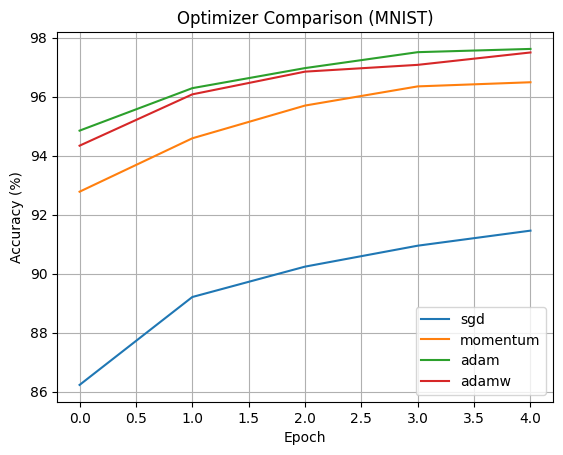

In [3]:
# ===== Data =====
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset  = torchvision.datasets.MNIST(root="./data", train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ===== Modell (MLP) =====
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

# ===== Träning =====
def train_model(optimizer_name, epochs=5):
    model = MLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    elif optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.001)

    acc_list = []

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # ===== Test accuracy =====
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        acc_list.append(accuracy)

        print(f"{optimizer_name} - Epoch {epoch+1}: {accuracy:.2f}%")

    return acc_list

# ===== Kör alla optimerare =====
optimizers = ["sgd", "momentum", "adam", "adamw"]
results = {}

for opt in optimizers:
    print(f"\nTraining with {opt}")
    results[opt] = train_model(opt, epochs=5)

# ===== Plot =====
plt.figure()

for opt in optimizers:
    plt.plot(results[opt], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Optimizer Comparison (MNIST)")
plt.legend()
plt.grid()

plt.show()

In [ ]:
######################################################################